Dimensiones de la matriz de la imagen: (256, 216, 10)
Tamaño real del vóxel (píxel en 3D) en mm: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))


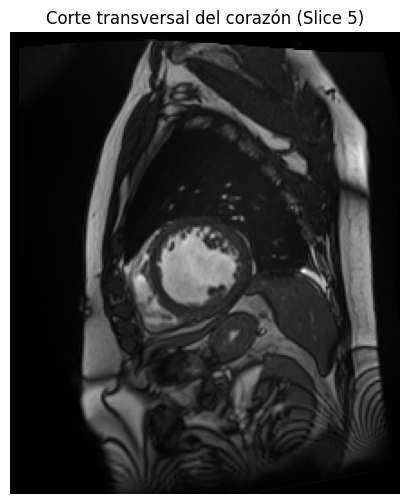

In [3]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir la ruta del archivo NIfTI (asegúrate de que exista)
# Los archivos suelen llamarse algo como patient001_frame01.nii.gz
ruta_imagen = '../data/patient001/patient001_frame01.nii.gz'

# 2. Cargar el objeto NIfTI y extraer la matriz matemática (píxeles)
nii_img = nib.load(ruta_imagen)
image_data = nii_img.get_fdata()
#procesamiento de orientación
image_data = np.rot90(image_data, k=-1, axes=(0, 1))
image_data = np.fliplr(image_data)

# 3. Leer los Metadatos clave
print(f"Dimensiones de la matriz de la imagen: {image_data.shape}")
print(f"Tamaño real del vóxel (píxel en 3D) en mm: {nii_img.header.get_zooms()}")

# 4. Visualización
# La imagen es 3D (X, Y, Z). Vamos a ver un "corte" (slice) a la mitad del eje Z.
corte_medio = image_data.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(image_data[:, :, corte_medio], cmap='gray')
plt.title(f"Corte transversal del corazón (Slice {corte_medio})")
plt.axis('off')
plt.show()

Dimensiones imagen: (256, 216, 10)
Dimensiones ground truth: (256, 216, 10)
Tamaño del vóxel (mm): (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))


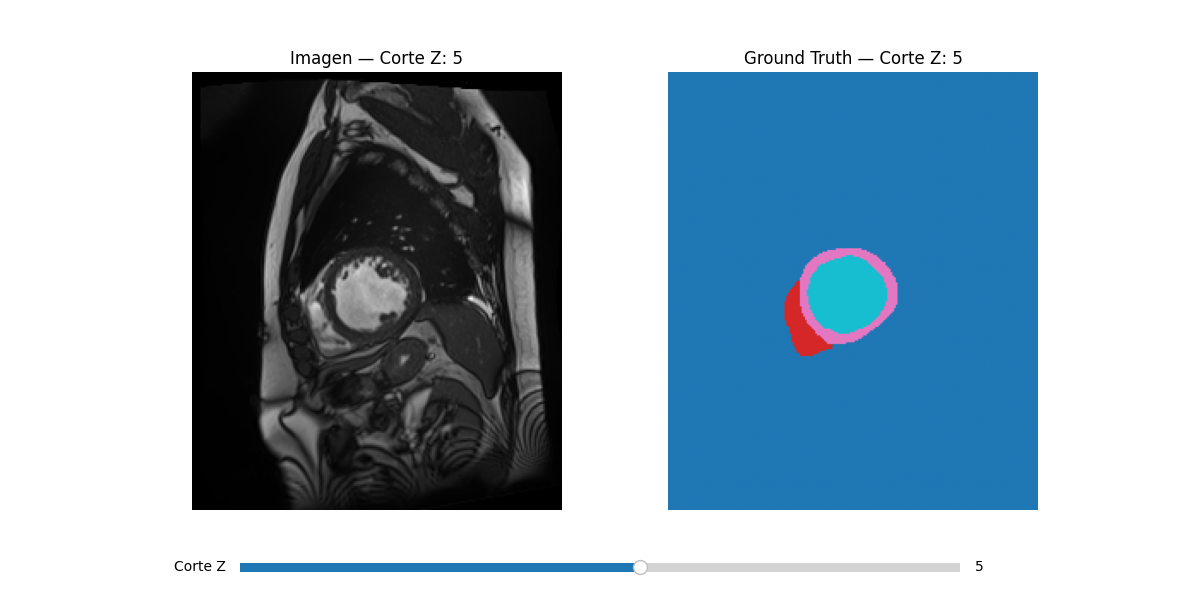

In [8]:
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

%matplotlib widget

# 1. Cargar imágenes
ruta_imagen = '../data/patient001/patient001_frame01.nii.gz'
ruta_gt = '../data/patient001/patient001_frame01_gt.nii.gz'

nii_img = nib.load(ruta_imagen)
nii_img_gt = nib.load(ruta_gt)

image_data = nii_img.get_fdata()
image_gt = nii_img_gt.get_fdata()

image_data = np.rot90(image_data, k=-1, axes=(0, 1))
image_data = np.fliplr(image_data)

image_gt = np.rot90(image_gt, k=-1, axes=(0, 1))
image_gt = np.fliplr(image_gt)

print(f"Dimensiones imagen: {image_data.shape}")
print(f"Dimensiones ground truth: {image_gt.shape}")
print(f"Tamaño del vóxel (mm): {nii_img.header.get_zooms()}")

num_slices = image_data.shape[2]
corte_inicial = num_slices // 2

# 2. Figura con dos columnas y espacio para el slider
fig, (ax_img, ax_gt) = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(bottom=0.15, wspace=0.05)

# 3. Imagen original (izquierda)
img_display = ax_img.imshow(image_data[:, :, corte_inicial], cmap='gray')
ax_img.set_title(f"Imagen — Corte Z: {corte_inicial}")
ax_img.axis('off')

# 4. Ground truth (derecha)
gt_display = ax_gt.imshow(image_gt[:, :, corte_inicial], cmap='tab10', vmin=0, vmax=3)
ax_gt.set_title(f"Ground Truth — Corte Z: {corte_inicial}")
ax_gt.axis('off')

# 5. Slider compartido (un solo slider controla ambas vistas)
ax_slider = plt.axes([0.2, 0.04, 0.6, 0.03])
slider = Slider(ax_slider, 'Corte Z', 0, num_slices - 1,
                valinit=corte_inicial, valstep=1)

# 6. Actualizar ambas imágenes al mover el slider
def actualizar(val):
    z = int(slider.val)
    img_display.set_data(image_data[:, :, z])
    gt_display.set_data(image_gt[:, :, z])
    ax_img.set_title(f"Imagen — Corte Z: {z}")
    ax_gt.set_title(f"Ground Truth — Corte Z: {z}")
    fig.canvas.draw_idle()

slider.on_changed(actualizar)
plt.show()

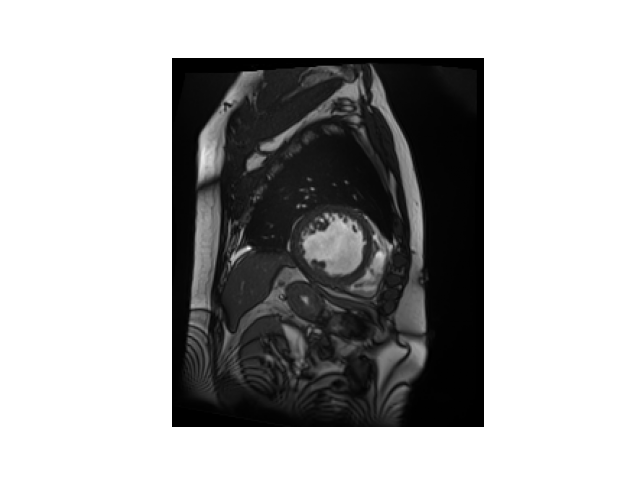

In [9]:
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Cargar el archivo 4D (.nii.gz)
ruta_imagen = '../data/patient001/patient001_4d.nii.gz'
img_4d = nib.load(ruta_imagen)
data = img_4d.get_fdata()
data = np.rot90(data, k=1, axes=(0, 1))
data = np.fliplr(data)


# Saber las dimensiones: (X, Y, Z, Frames)
x_dim, y_dim, z_dim, total_frames = data.shape

# 2. Elegir un corte intermedio del eje Z para visualizarlo bien
middle_slice = z_dim // 2

# 3. Configurar la figura para la animación
fig, ax = plt.subplots()
ax.axis('off')  # Ocultar ejes

# Mostrar el primer frame
im = ax.imshow(data[:, :, middle_slice, 0], cmap='gray', origin='lower')

# 4. Función de actualización para cada frame de la animación
def update(frame_index):
    # Actualiza la imagen con el frame correspondiente en el tiempo
    im.set_array(data[:, :, middle_slice, frame_index])
    ax.set_title(f"Frame {frame_index + 1} / {total_frames}")
    return [im]

# 5. Crear la animación
ani = animation.FuncAnimation(
    fig, update, frames=total_frames, interval=200, blit=True
)

plt.show()
